# Evaluating the LFADS fit — kcEXP00H

This notebook is the kcEXP00H analogue of `tutorials/multisession/3_evaluation.ipynb`.
That tutorial evaluates a *spike* model on the Rouse reaching data; here we evaluate the
multisession LFADS model trained by `2_run_pbt_kcEXP00H.py` on **z-scored ΔF/F** region
traces (5 flies, 69 regions each, 175 frames/trial).

Because the data is continuous ΔF/F (Gaussian reconstruction) rather than Poisson spikes,
two things differ from the tutorial:

- `output_params` is the **reconstructed ΔF/F mean** (not a firing rate in Hz). We compare it
  directly to the ground-truth `recon_data` — no `/bin_width` conversion, no spike-smoothing
  baseline.
- The reconstruction quality metric is **R² / variance-accounted-for** on the z-scored signal.

**What "how well did training do" means here, in four checks:**

1. **Reconstruction R²** — does the model explain the held-out (valid) trials, not just train?
   (overfitting check, given only 14 train / 4 valid trials per fly).
2. **Single-trial denoising** — eyeball input vs reconstruction vs the 50 latent factors.
3. **Condition-PSTH faithfulness** — does the reconstruction preserve the stimulus-condition
   structure of the raw data?
4. **Latent state-space** — do the factors form a shared, condition-organized geometry across flies?

The *downstream usefulness* half (decoding odor/walk/vision from the factors) lives in
`4_decode_stimulus_kcEXP00H.ipynb`; see also `tutorials/multisession/3_evaluation_explained.md`.

## Parameters

In [1]:
import re
import sys
from glob import glob
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# --- Directory containing lfads_output_*.h5 (written by run_posterior_sampling at the
#     end of 2_run_pbt_kcEXP00H.py, inside the run's best_model/ folder). ---
# Leave as None to auto-pick the most recent run; or set explicitly to a best_model dir.
H5_DIR = None
if H5_DIR is None:
    # cands = sorted(Path('../runs').glob(
        # 'kcEXP00H_multisession_202606291751/pbt/*/*/best_model'))
    cands = sorted(Path('../runs').glob(
        'kcEXP00H_multisession_202607161710/pbt/*/*/best_model'))
    cands = [c for c in cands if list(c.glob('lfads_output_*.h5'))]
    assert cands, "No best_model with lfads_output_*.h5 found under ../runs"
    H5_DIR = cands[-1]
H5_DIR = Path(H5_DIR)
print("Using LFADS outputs from:", H5_DIR)

# --- Source xarray (.nc) files: needed only for per-trial condition labels (PSTHs / colors) ---
XARRAY_DIR = (
    '/media/server/gklab/KarenCheng/DATA/LFM_current/'
    'kcEXP00H/kcEXP00H_PythonNotebooks/xarray_files/'
)

# The 8 stimulus conditions (V=vision, O=odor, F=forward-walk; x = off).
COND_ORDER = ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

Using LFADS outputs from: ../runs/kcEXP00H_multisession_202607161710/pbt/kcEXP00H_multisession_KC1pt2/260716/best_model


## Load LFADS outputs

Same `merge_train_valid` helper as the evaluation/decode notebooks. Two carried-over gotchas:

- `train_inds` / `valid_inds` are stored as **float32** — cast to `int` before fancy-indexing.
- We keep **train and valid separate** for the reconstruction metric (valid = held-out quality),
  but also build a **merged** copy (original trial order) for the per-condition / state-space plots.

`recon_data` is the ground-truth z-scored ΔF/F target; `output_params` is the model's
reconstruction of it; `factors` are the 50-D latents.

In [2]:
def merge_train_valid(train_data, valid_data, train_inds, valid_inds):
    n = len(train_data) + len(valid_data)
    merged = np.full((n, *train_data.shape[1:]), np.nan, dtype=train_data.dtype)
    merged[train_inds] = train_data
    merged[valid_inds] = valid_data
    return merged

h5_paths = sorted(glob(str(H5_DIR / 'lfads_output_*.h5')))
assert h5_paths, f"No lfads_output_*.h5 in {H5_DIR}"

flies = []                # h5 stems, one per fly
truth, pred, factors = {}, {}, {}     # merged (n_trials, n_time, .) in original trial order
split = {}                # 'train'/'valid' arrays for the held-out R^2 metric
for path in h5_paths:
    fly = Path(path).stem.replace('lfads_output_', '')
    flies.append(fly)
    with h5py.File(path) as f:
        ti = f['train_inds'][()].astype(int)
        vi = f['valid_inds'][()].astype(int)
        truth[fly]   = merge_train_valid(f['train_recon_data'][()],
                                         f['valid_recon_data'][()], ti, vi)
        pred[fly]    = merge_train_valid(f['train_output_params'][()],
                                         f['valid_output_params'][()], ti, vi)
        factors[fly] = merge_train_valid(f['train_factors'][()],
                                         f['valid_factors'][()], ti, vi)
        split[fly] = dict(
            train=(f['train_recon_data'][()], f['train_output_params'][()]),
            valid=(f['valid_recon_data'][()], f['valid_output_params'][()]),
        )
    print(f"  {fly}: truth/pred {truth[fly].shape}, factors {factors[fly].shape}")

n_fac = next(iter(factors.values())).shape[-1]
n_time = next(iter(factors.values())).shape[1]
print(f"\n{len(flies)} flies | n_factors = {n_fac} | n_time = {n_time}")

  lfads_H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP: truth/pred (16, 1050, 67), factors (16, 1050, 50)
  lfads_H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: truth/pred (16, 1050, 67), factors (16, 1050, 50)
  lfads_H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP: truth/pred (16, 1050, 67), factors (16, 1050, 50)
  lfads_H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: truth/pred (16, 1050, 66), factors (16, 1050, 50)
  lfads_H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP: truth/pred (16, 1050, 67), factors (16, 1050, 50)

5 flies | n_factors = 50 | n_time = 1050


## Load per-trial condition labels

Read the `condition` coordinate straight from each source `.nc` (a `(trial,)` array of strings like
`VOF`, `xOx`, ...). We match each LFADS output to its `.nc` by filename stem. `merge_train_valid`
restored the original 0..N trial order — the same order the xarray stores trials in — so labels line
up trial-for-trial with the factors.

In [ ]:
import xarray as xr

# condition labels keyed by .nc filename stem (e.g. 'H30003-005_..._DVAP')
cond_by_ncstem = {}
for p in sorted(glob(str(Path(XARRAY_DIR) / '*.nc'))):
    with xr.open_dataset(p) as ds:
        cond_by_ncstem[Path(p).stem] = \
            np.asarray(ds['condition'].values).reshape(-1).astype(str)

# 1.2_data_prep_KC drops the 2 baseline trials (positional [0, 9]) before saving, so its h5s
# have 16 trials while the .nc condition array still has 18. Drop the same trials to realign.
# (1-1 keeps all 18, so only drop when the counts differ by exactly these 2.)
BASELINE_TRIALS = [0, 9]

def match_conditions(fly, nt): 
    # the .nc stem appears inside the LFADS output fly stem (which has a 'lfads_' prefix)
    matches = [s for s in cond_by_ncstem if s in fly]
    if len(matches) != 1:
        raise KeyError(f"{fly}: matched {matches} (expected exactly 1)")
    conds = cond_by_ncstem[matches[0]]
    if len(conds) == nt + len(BASELINE_TRIALS):   # 1.2 data: baseline trials were dropped
        conds = np.delete(conds, BASELINE_TRIALS)
    return conds

conditions = {}   # fly -> (n_trials,) str
for fly in flies:
    nt = truth[fly].shape[0]
    conditions[fly] = match_conditions(fly, nt)
    assert len(conditions[fly]) == nt, (fly, len(conditions[fly]), nt)
    uniq, cnt = np.unique(conditions[fly], return_counts=True)
    print(f"  {fly}: " + " ".join(f"{u}={c}" for u, c in zip(uniq, cnt)))

  lfads_H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP: VOF=2 VOx=2 VxF=2 Vxx=2 xOF=2 xOx=2 xxF=2 xxx=2
  lfads_H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: VOF=2 VOx=2 VxF=2 Vxx=2 xOF=2 xOx=2 xxF=2 xxx=2
  lfads_H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP: VOF=2 VOx=2 VxF=2 Vxx=2 xOF=2 xOx=2 xxF=2 xxx=2
  lfads_H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: VOF=2 VOx=2 VxF=2 Vxx=2 xOF=2 xOx=2 xxF=2 xxx=2
  lfads_H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP: VOF=2 VOx=2 VxF=2 Vxx=2 xOF=2 xOx=2 xxF=2 xxx=2


## 1 — Reconstruction R² (train vs held-out valid)

Variance-accounted-for on the z-scored ΔF/F, computed over all (trial, time, region) entries.
Because the signal is z-scored, the per-fly baseline variance is ~1, so R² is directly comparable
across flies.

- **Train R²** = how well the model fit the data it saw.
- **Valid R²** = how well it generalizes to held-out trials. With only 4 valid trials/fly this is
  noisy, but **train ≫ valid** would flag overfitting; **train ≈ valid** is the healthy outcome.

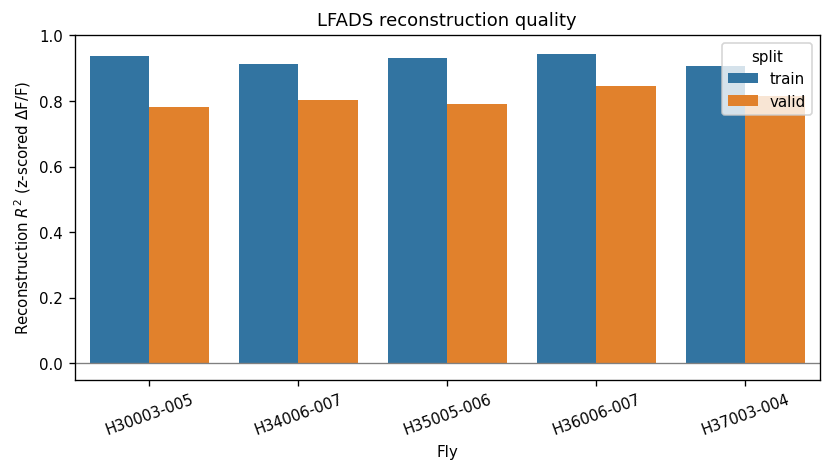

split       train  valid
fly_short               
H30003-005  0.937  0.781
H34006-007  0.913  0.804
H35005-006  0.932  0.790
H36006-007  0.943  0.847
H37003-004  0.907  0.816

Mean train R2 = 0.926 | mean valid R2 = 0.807


In [ ]:
import pandas as pd

def r2(y, yhat):
    y = y.reshape(-1); yhat = yhat.reshape(-1)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot

rows = []
for fly in flies:
    for part in ('train', 'valid'):
        yt, yp = split[fly][part]
        rows.append(dict(fly=fly, split=part, r2=r2(yt, yp)))
recon_df = pd.DataFrame(rows)

# Compact fly labels for plotting (e.g. 'H30003-005')
    def _short(fly):
    m = re.search(r'H\d+-\d+', fly)
    return m.group() if m else fly
short = {fly: _short(fly) for fly in flies}
recon_df['fly_short'] = recon_df['fly'].map(short)

import seaborn as sns
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(recon_df, x='fly_short', y='r2', hue='split',
            hue_order=['train', 'valid'], ax=ax)
ax.axhline(0, color='grey', lw=0.8)
ax.set_ylim(min(0, recon_df.r2.min()) - 0.05, 1)
ax.set_xlabel('Fly'); ax.set_ylabel('Reconstruction $R^2$ (z-scored ΔF/F)')
ax.set_title('LFADS reconstruction quality')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

print(recon_df.pivot(index='fly_short', columns='split', values='r2').round(3))
print("\nMean train R2 = {:.3f} | mean valid R2 = {:.3f}".format(
    recon_df[recon_df.split == 'train'].r2.mean(),
    recon_df[recon_df.split == 'valid'].r2.mean()))

## 2 — Single-trial denoising

For one trial of one fly: ground-truth ΔF/F → LFADS reconstruction → the 50 latent factors.
A good fit reproduces the structured spatiotemporal pattern of the data (left vs middle) while the
factors (right) compress it to the shared latent space. Below the heatmaps we overlay a few region
traces (truth vs reconstruction) for a closer look.

To reconstruct ts, LFADS applies a "per-session linear (affine) readout" independently at each timepoint. BASICALLY, take the 50 factor traces, matrix-multiply by that fly's W_out, add b_out

output_params[trial, t, :] = W_out · factors[trial, t, :] + b_out

W_out: (n_regions x n_latents); PCR-initialized as pinv(readin_weight)

b_out is (n_regions, ); the readout_bias


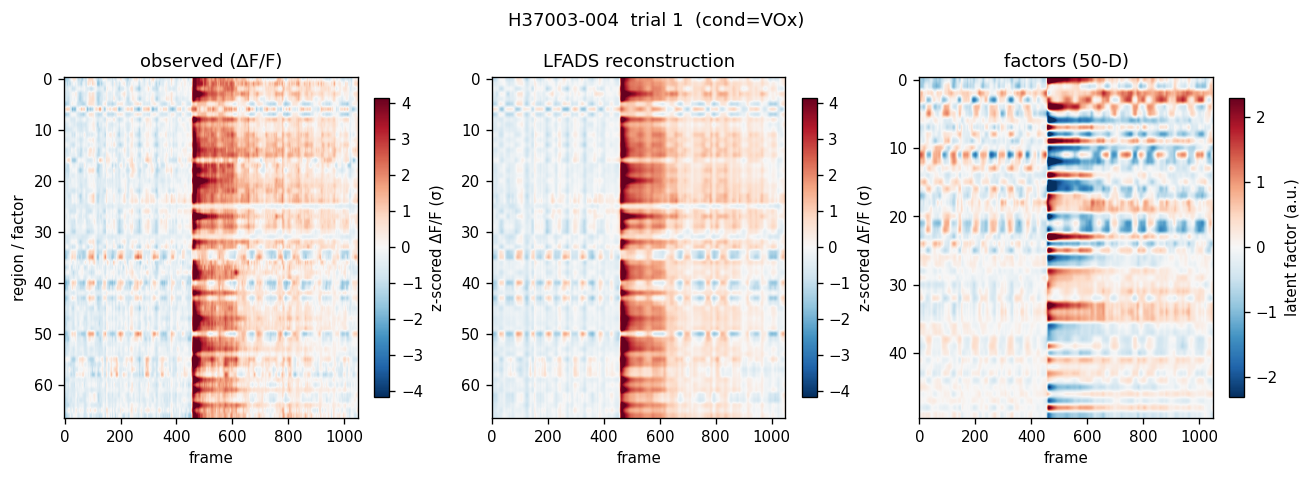

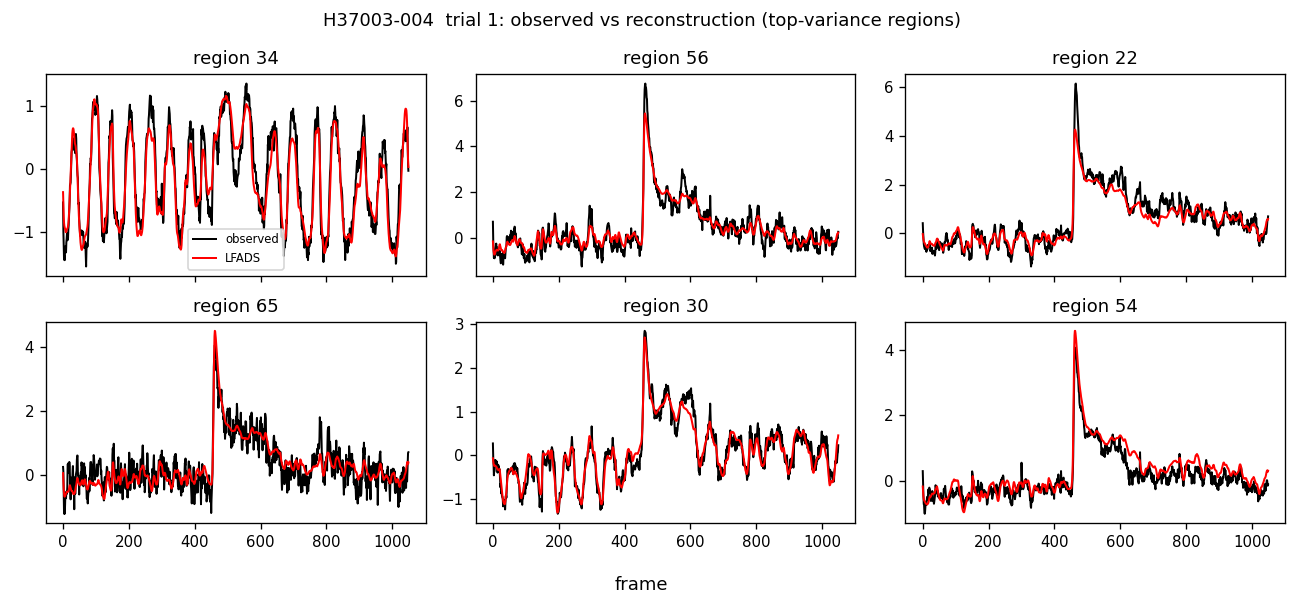

In [17]:
fly = flies[4]
trial = 1

# (array, kind) — kind sets the colorbar range/label. observed & reconstruction share the
# z-scored ΔF/F range; factors are unitless latent activations with their own range.
panels = {
    'observed (ΔF/F)':       (truth[fly][trial],   'dff'),
    'LFADS reconstruction':  (pred[fly][trial],    'dff'),
    f'factors ({n_fac}-D)':  (factors[fly][trial], 'fac'),
}
# shared symmetric range for the two ΔF/F panels; separate range for factors
dff_vmax = np.nanpercentile(np.abs(np.concatenate([truth[fly][trial], pred[fly][trial]])), 99)
cbar_label = {'dff': 'z-scored ΔF/F (σ)', 'fac': 'latent factor (a.u.)'}

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, (name, (arr, kind)) in zip(axes, panels.items()):
    vmax = dff_vmax if kind == 'dff' else np.nanpercentile(np.abs(arr), 99)
    im = ax.imshow(arr.T, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(name); ax.set_xlabel('frame')
    fig.colorbar(im, ax=ax, fraction=0.046, label=cbar_label[kind])
axes[0].set_ylabel('region / factor')
fig.suptitle(f'{short[fly]}  trial {trial}  (cond={conditions[fly][trial]})')
plt.tight_layout(); plt.show()

# Region-trace overlay: highest-variance regions for this fly
reg_var = truth[fly].reshape(-1, truth[fly].shape[-1]).var(0)
regs = np.argsort(reg_var)[::-1][:6]
fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharex=True)
for ax, r in zip(axes.flatten(), regs):
    ax.plot(truth[fly][trial, :, r], 'k', lw=1.2, label='observed')
    ax.plot(pred[fly][trial, :, r], 'r', lw=1.2, label='LFADS')
    ax.set_title(f'region {r}')
axes[0, 0].legend(fontsize=7)
fig.suptitle(f'{short[fly]}  trial {trial}: observed vs reconstruction (top-variance regions)')
fig.supxlabel('frame'); plt.tight_layout(); plt.show()

## 3 — Condition-PSTH faithfulness

The tutorial's PSTH check, adapted: average each region's activity across trials **within each
stimulus condition**, and overlay truth vs reconstruction. If the model is faithful, the
reconstruction PSTHs (dashed) track the data PSTHs (solid) per condition — but smoother, because
LFADS pools across the population and the learned dynamics.

One figure per fly (top-variance regions). If reconstruction (dashed) doesn't track the data (solid)
across conditions, the model isn't capturing the fly's stimulus structure.

> Caveat: ~18 trials / 8 conditions ≈ 2 trials per condition per fly (`xxx` has 4), so PSTHs are
> noisy. This is a qualitative faithfulness check, not a denoised estimate.

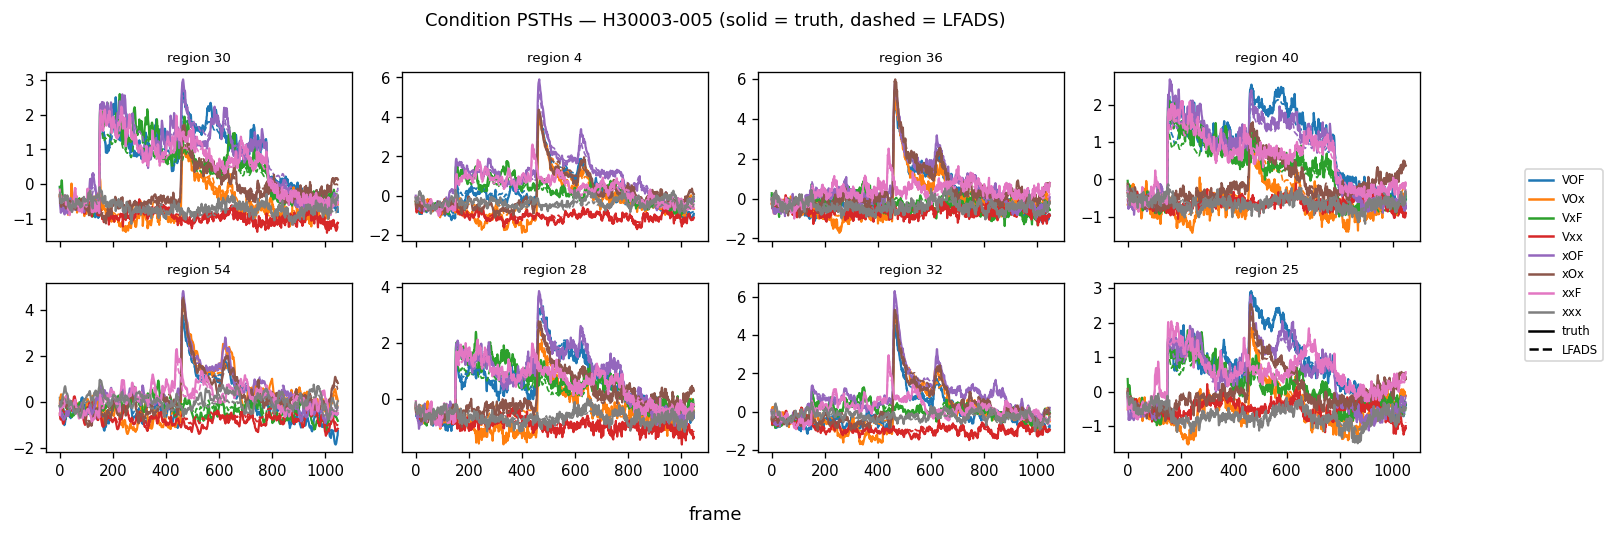

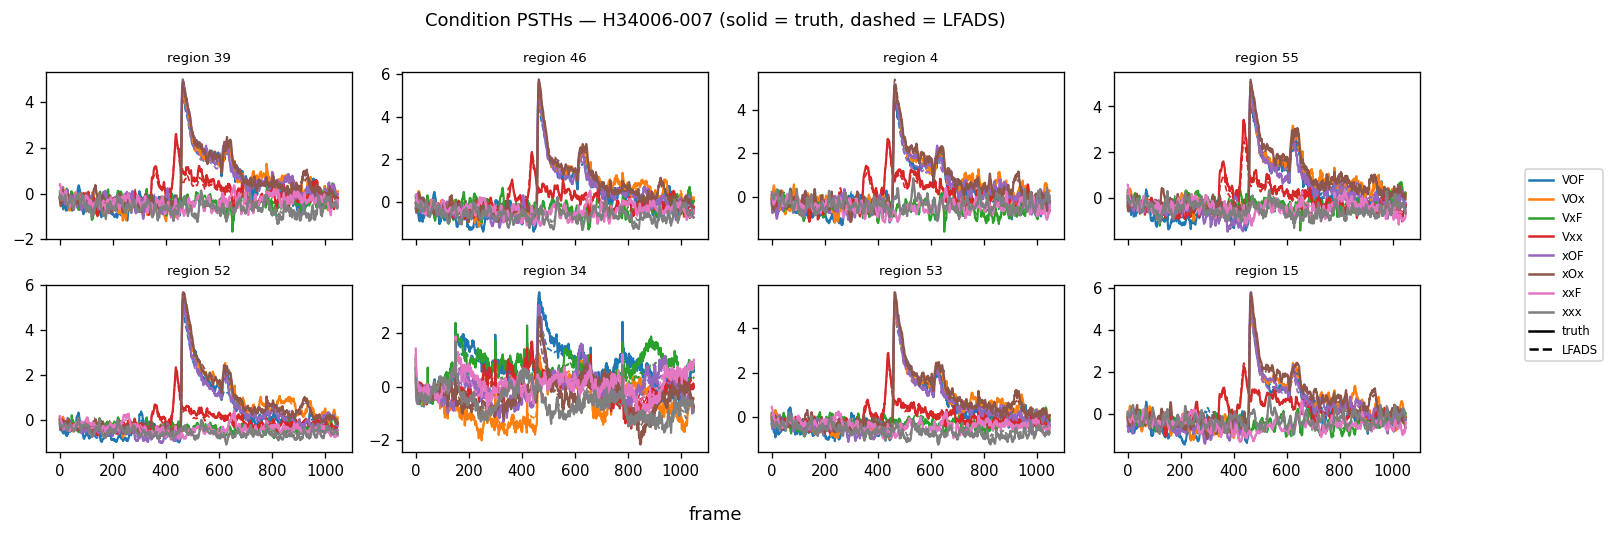

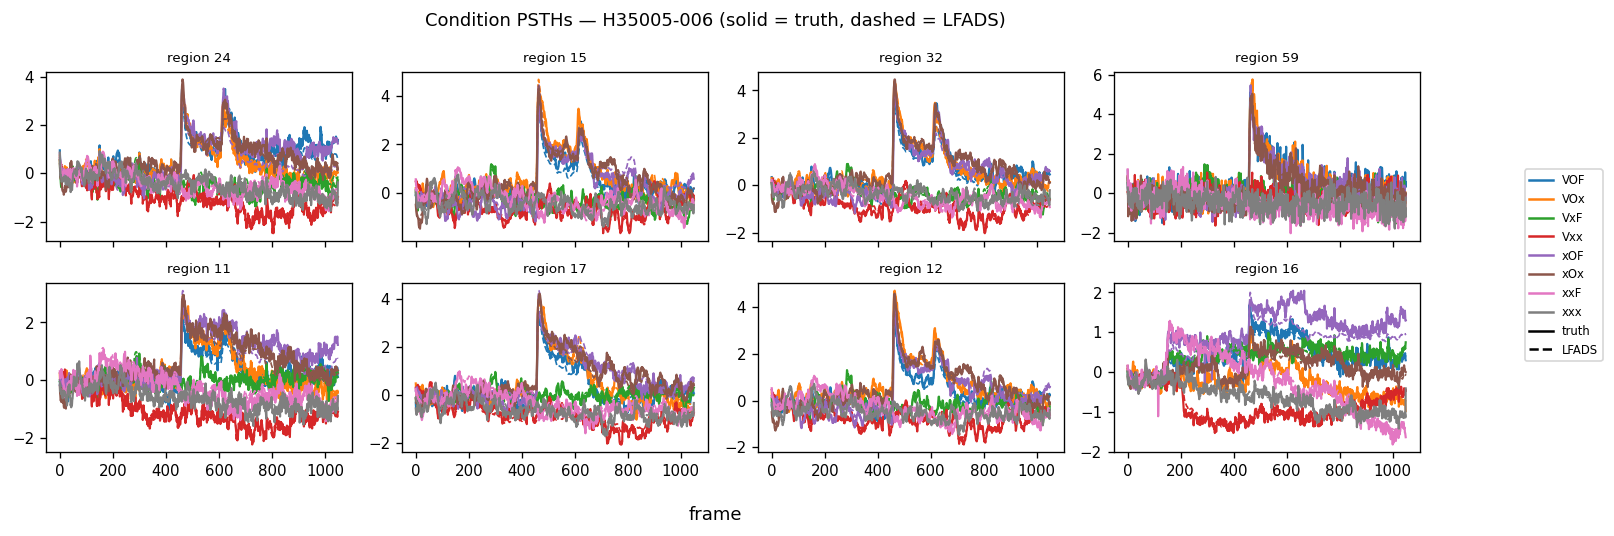

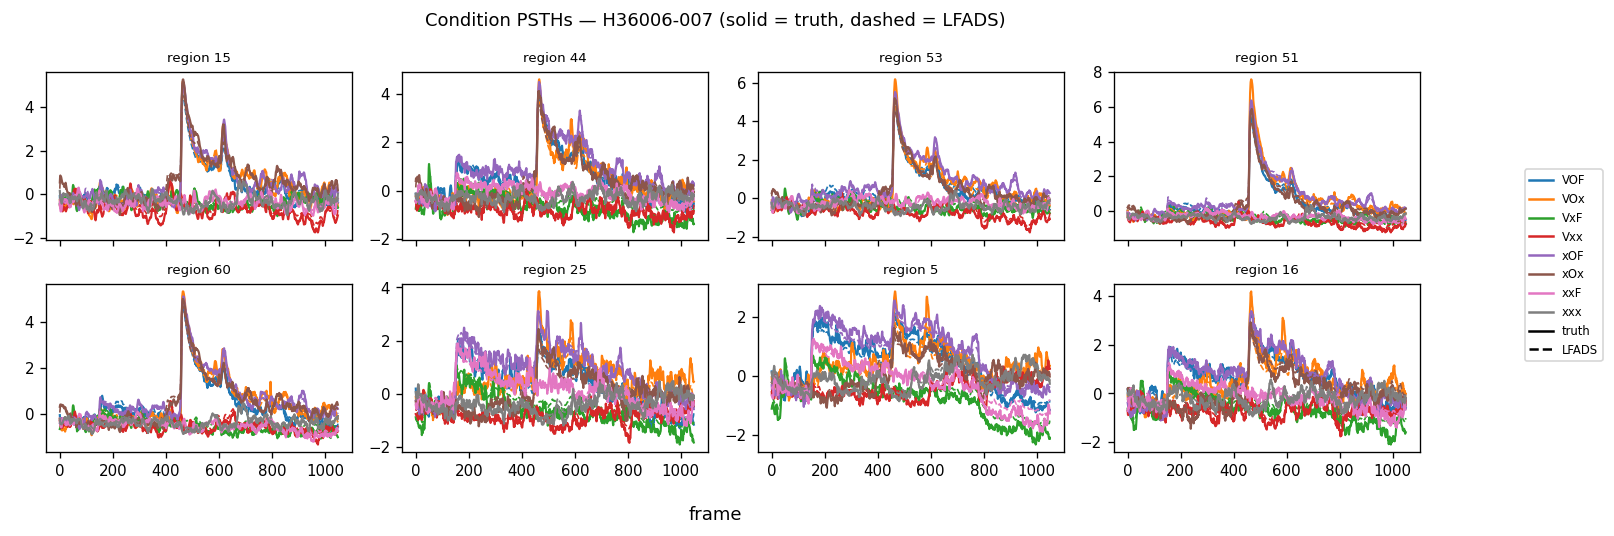

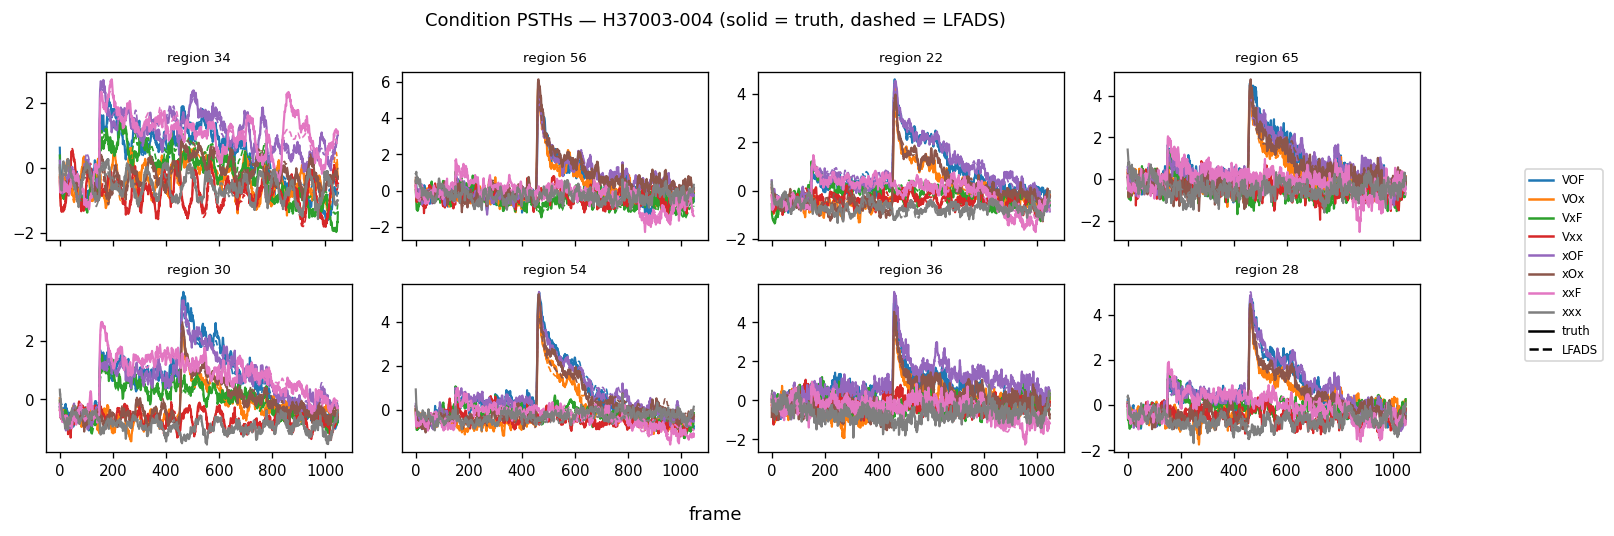

In [6]:
from matplotlib import cm

def plot_condition_psths(fly, regions, title):
    conds = conditions[fly]
    present = [c for c in COND_ORDER if (conds == c).any()]
    colors = {c: cm.tab10(i % 10) for i, c in enumerate(COND_ORDER)}
    ncol = 4
    nrow = int(np.ceil(len(regions) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3 * ncol, 2.2 * nrow),
                             sharex=True)
    for ax, r in zip(np.atleast_1d(axes).flatten(), regions):
        for c in present:
            m = conds == c
            ax.plot(truth[fly][m, :, r].mean(0), color=colors[c], lw=1.3)
            ax.plot(pred[fly][m, :, r].mean(0), color=colors[c], lw=1.0, ls='--')
        ax.set_title(f'region {r}', fontsize=8)
    # legend (solid = truth, dashed = LFADS) + condition colors
    handles = [plt.Line2D([], [], color=colors[c], label=c) for c in present]
    handles += [plt.Line2D([], [], color='k', label='truth'),
                plt.Line2D([], [], color='k', ls='--', label='LFADS')]
    fig.legend(handles=handles, loc='center right', fontsize=7,
               bbox_to_anchor=(1.12, 0.5))
    fig.suptitle(title); fig.supxlabel('frame')
    plt.tight_layout(); plt.show()

for fly in flies:
    reg_var = truth[fly].reshape(-1, truth[fly].shape[-1]).var(0)
    top_regs = np.argsort(reg_var)[::-1][:8]
    plot_condition_psths(fly, top_regs, f'Condition PSTHs — {short[fly]} '
                                        '(solid = truth, dashed = LFADS)')

## 4 — Latent state-space

One PCA fit across **all flies' factors**, then per-fly 3-D trajectories colored by stimulus
condition (parallel to the Rouse tutorial's reach-direction trajectories). If the multisession
model found a **shared, fly-invariant** latent code, the per-fly subplots look alike and the same
condition occupies the same region of factor space across flies.

explained variance (PC1-3): [0.501 0.137 0.105]  sum = 0.743


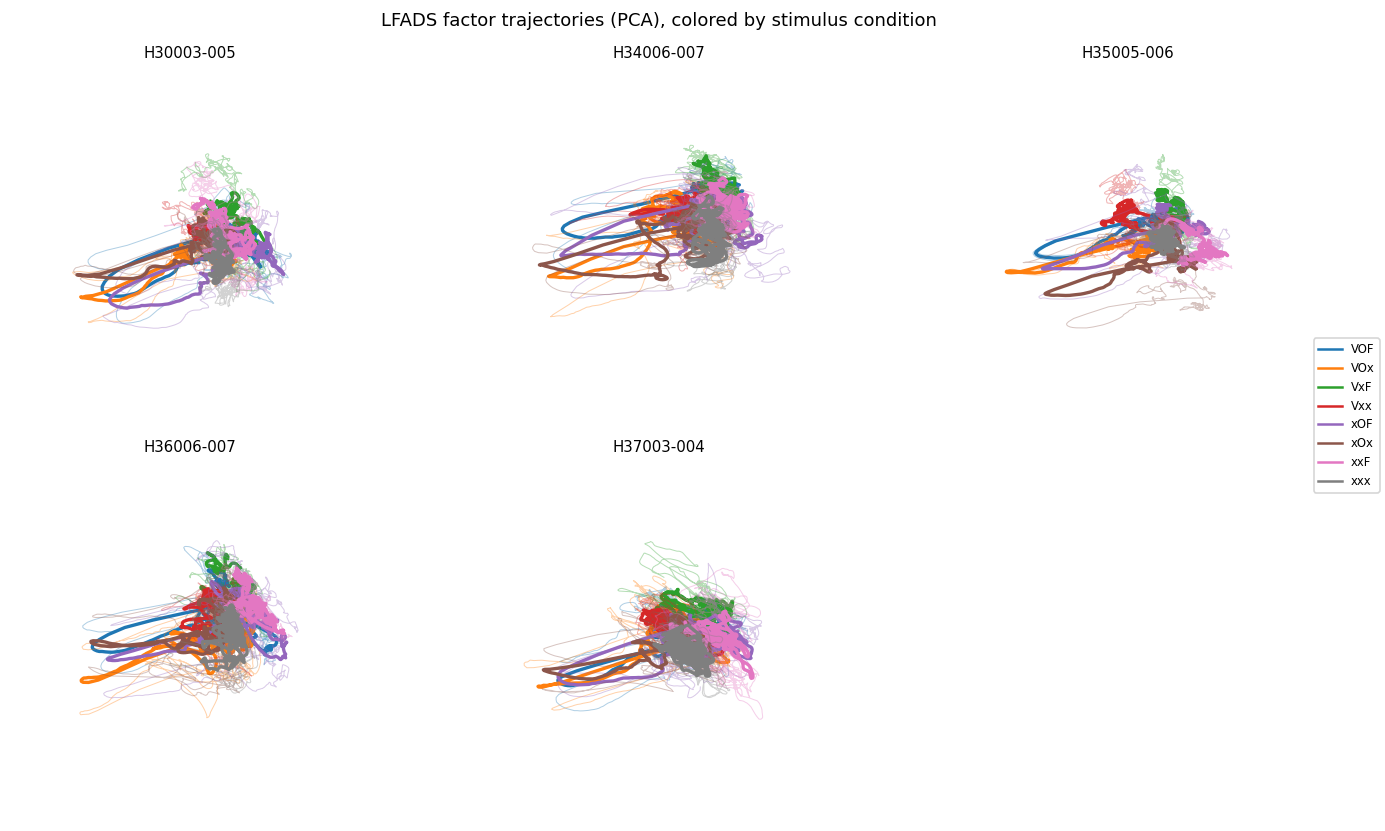

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Fit one PCA + scaler on all factors pooled across flies
all_fac = np.concatenate([factors[f].reshape(-1, n_fac) for f in flies], 0)
ss = StandardScaler().fit(all_fac)
pca = PCA(n_components=3).fit(ss.transform(all_fac))
print("explained variance (PC1-3):", np.round(pca.explained_variance_ratio_, 3),
      " sum =", round(pca.explained_variance_ratio_[:3].sum(), 3))

colors = {c: cm.tab10(i % 10) for i, c in enumerate(COND_ORDER)}
ncol = min(len(flies), 3)
nrow = int(np.ceil(len(flies) / ncol))
fig = plt.figure(figsize=(4 * ncol, 3.5 * nrow))
for i, fly in enumerate(flies):
    ax = fig.add_subplot(nrow, ncol, i + 1, projection='3d')
    f3 = pca.transform(ss.transform(factors[fly].reshape(-1, n_fac)))
    f3 = f3.reshape(factors[fly].shape[0], n_time, 3)
    conds = conditions[fly]
    for c in [c for c in COND_ORDER if (conds == c).any()]:
        for tr in np.where(conds == c)[0]:
            ax.plot(*f3[tr].T, color=colors[c], alpha=0.35, lw=0.6)
        ax.plot(*f3[conds == c].mean(0).T, color=colors[c], lw=2)
    ax.set_title(short[fly], fontsize=9); ax.axis('off')
    ax.view_init(elev=15., azim=37.5)
handles = [plt.Line2D([], [], color=colors[c], label=c)
           for c in COND_ORDER]
fig.legend(handles=handles, loc='center right', fontsize=7, ncol=1)
fig.suptitle('LFADS factor trajectories (PCA), colored by stimulus condition')
plt.tight_layout(); plt.show()

### 4b/4c — "So much overlap": distinct or not?

The PC1-3 cloud above looks tangled, but that's mostly an artifact of two things, not evidence that
conditions are indistinct:

1. **PC1 (~53% of variance) is a stimulus-locked ramp shared by *every* condition.** It points the
   same way for all 8 conditions, so it piles them on top of each other. Setting it aside (PC2-4)
   and plotting **condition means** (pooled across flies) pulls the conditions apart — cell **4b**.
2. **~2 trials/condition/fly** means the faint single-trial lines are dominated by trial-to-trial
   noise. The thick condition-mean lines are the fair comparison.

Cell **4c** quantifies this: a *between-condition vs within-condition* variance ratio near 1 means
"distinct but overlapping at the single-trial level," **not** "collapsed." The real test of whether
conditions are separable is whether a decoder can read them out — that's
`4_decode_stimulus_kcEXP00H.ipynb`.

explained variance PC1-6: [0.501 0.137 0.105 0.074 0.056 0.043]


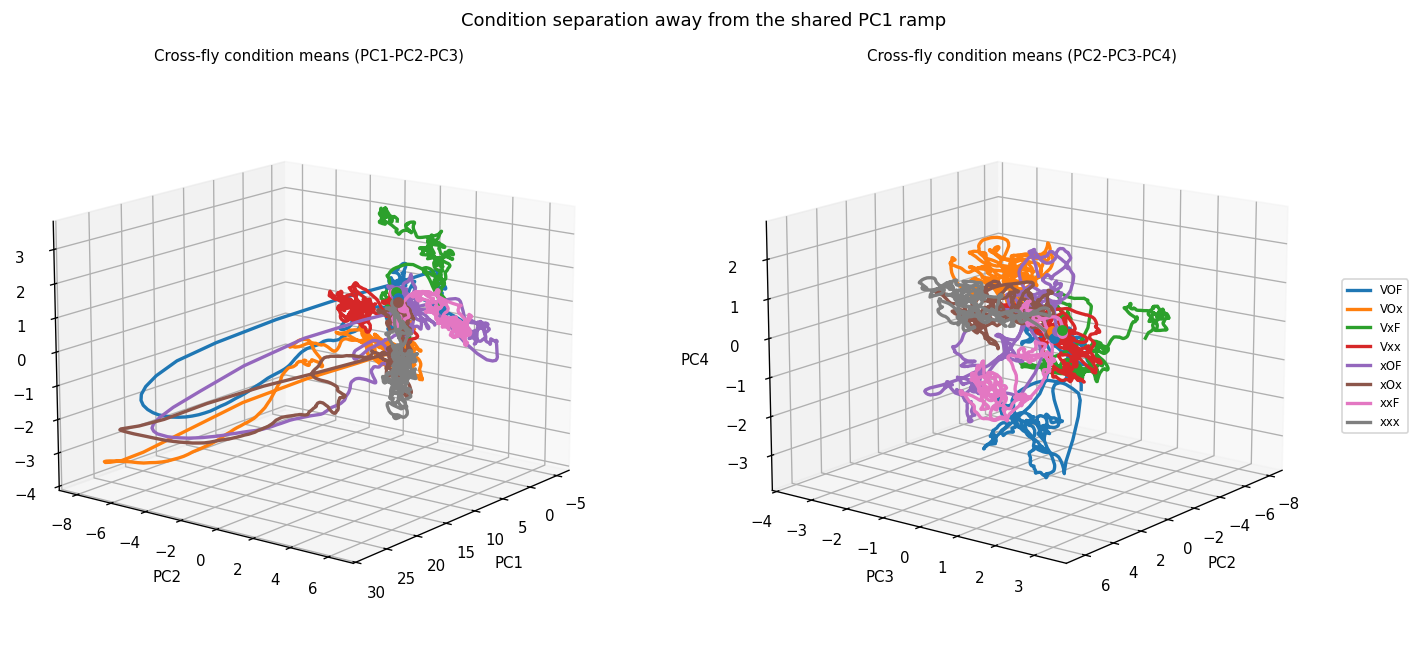

In [8]:
# --- 4b. Look past PC1: cross-fly condition-MEAN trajectories ---
# PC1 holds ~53% of the variance but is dominated by a stimulus-locked ramp shared by every
# condition, so the raw PC1-3 cloud looks tangled. Refit PCA with more components and plot the
# condition means (pooled across flies) in PC1-3 vs PC2-4. Conditions separate much more once
# the shared PC1 ramp is set aside.
pca10 = PCA(n_components=10).fit(ss.transform(all_fac))
ss10 = ss            # same scaler; alias for clarity
print("explained variance PC1-6:", np.round(pca10.explained_variance_ratio_[:6], 3))

# precompute each fly's factors in the 10-D PCA space, reshaped to (trials, time, 10)
fac10 = {f: pca10.transform(ss10.transform(factors[f].reshape(-1, n_fac)))
              .reshape(factors[f].shape[0], n_time, 10) for f in flies}

fig = plt.figure(figsize=(13, 5.5))
for j, (pcs, lab) in enumerate([((0, 1, 2), 'PC1-PC2-PC3'),
                                ((1, 2, 3), 'PC2-PC3-PC4')]):
    ax = fig.add_subplot(1, 2, j + 1, projection='3d')
    for c in COND_ORDER:
        means = [fac10[f][conditions[f] == c].mean(0)
                 for f in flies if (conditions[f] == c).any()]
        mt = np.mean(means, 0)[:, list(pcs)]                  # cross-fly mean traj
        ax.plot(*mt.T, color=colors[c], lw=2, label=c)
        ax.scatter(*mt[0], color=colors[c], s=30)            # start point
    ax.set_title(f'Cross-fly condition means ({lab})', fontsize=9)
    xl, yl, zl = lab.split('-')
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_zlabel(zl)
    ax.view_init(elev=15., azim=37.5)
ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(1.05, 0.5))
fig.suptitle('Condition separation away from the shared PC1 ramp')
plt.tight_layout(); plt.show()


In [9]:
# --- 4c. Is the overlap real, or just a shared ramp + few trials? ---
# (i) How much of PC1 is a stimulus-locked ramp COMMON to every condition?
grand = np.concatenate([factors[f] for f in flies], 0).mean(0)        # (time, n_fac) grand-mean traj
g3 = pca10.transform(ss10.transform(grand))[:, :3]
print("Grand-mean (all-condition) trajectory range per PC:",
      "PC1={:.1f}  PC2={:.1f}  PC3={:.1f}".format(*np.ptp(g3, 0)),
      "\n-> a large PC1 range means PC1 is mostly a shared temporal ramp, not a condition signal.\n")

# (ii) Condition separability in the full latent space (time-averaged per trial):
#      between-condition variance vs within-condition trial scatter. Ratio >> 1 = well separated.
print("Condition separability (50-D, time-averaged per trial):")
for fly in flies:
    X = factors[fly].mean(1)                                          # (trials, n_fac)
    conds = conditions[fly]
    present = [c for c in COND_ORDER if (conds == c).any()]
    cmeans = np.array([X[conds == c].mean(0) for c in present])
    between = cmeans.var(0).sum()
    within = np.mean([X[conds == c].var(0).sum()
                      for c in present if (conds == c).sum() > 1])
    print(f"  {short[fly]}: between={between:.2f}  within={within:.2f}  ratio={between/within:.2f}")
print("\nRatio near 1 = condition differences are comparable to trial-to-trial noise"
      " (distinct but overlapping, given ~2 trials/condition), NOT collapsed.")


Grand-mean (all-condition) trajectory range per PC: PC1=15.1  PC2=5.1  PC3=2.0 
-> a large PC1 range means PC1 is mostly a shared temporal ramp, not a condition signal.

Condition separability (50-D, time-averaged per trial):
  H30003-005: between=3.76  within=3.43  ratio=1.09
  H34006-007: between=2.82  within=1.80  ratio=1.57
  H35005-006: between=5.65  within=3.30  ratio=1.71
  H36006-007: between=4.22  within=1.88  ratio=2.25
  H37003-004: between=3.71  within=2.38  ratio=1.56

Ratio near 1 = condition differences are comparable to trial-to-trial noise (distinct but overlapping, given ~2 trials/condition), NOT collapsed.


## Summary

- **Reconstruction R²** (check 1) is the headline number for "did training work": valid R² well
  above 0 means the model captures real structure; **train ≈ valid** means it isn't just memorizing
  the 14 training trials.
- **Single-trial** (check 2) and **PSTH** (check 3) plots confirm the reconstruction is *faithful* —
  it reproduces the data's spatiotemporal and condition structure rather than collapsing to the mean.
- **State-space** (check 4): consistent per-fly geometry = the multisession model learned a shared
  latent code despite each fly having a different region set.

If valid R² is low or PSTHs don't track, revisit the PBT search (`2_run_pbt_kcEXP00H.py`) — e.g.
the KL/L2 ranges or `model.dropout_rate` — rather than the data prep.

**Next:** `4_decode_stimulus_kcEXP00H.ipynb` tests whether these factors are *useful* (decoding
odor / walk / vision, within- and across-fly); `5_region_contributions_kcEXP00H.ipynb` maps factors
back onto brain regions.